In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = "/home/ahasan/projects/hardware-aware-router/data/router_eval_runs/eval_summary_both_routers_200_0.2.csv"
df = pd.read_csv(csv_path, engine="python")


# Sanity check
df.head()


,run_id,router,lambda_score,arrival_rate,pattern_type,num_prompts,num_completed,avg_ttft_real,avg_tpot_real,avg_latency_real,...,gpu_0_avg_waiting,gpu_0_avg_kv_cache,gpu_1_avg_running,gpu_1_avg_waiting,gpu_1_avg_kv_cache,dispatch_count_model_Qwen2.5-3B-Instruct,dispatch_count_model_Llama-3.1-8B-Instruct,dispatch_count_model_Mistral-7B-Instruct-v0.3,dispatch_count_gpu_1,dispatch_count_gpu_0
0,20251118-003641,carrot,0.2,15.0,sustained,300,300,9.605914,0.026605,19.064856,...,0.000000,0.000000,5.792683,5.709350,0.283333,203,96,1,300,0
1,20251118-003924,carrot,0.2,18.0,sustained,300,300,8.353736,0.026729,17.643672,...,0.000000,0.000000,6.222222,5.397778,0.285000,203,96,1,300,0
2,20251118-004154,carrot,0.2,21.0,sustained,300,300,8.953920,0.026736,18.522700,...,0.000000,0.000000,6.084388,5.529536,0.285391,203,96,1,300,0
3,20251118-004431,hw,0.2,15.0,sustained,300,300,0.308040,0.025225,7.109631,...,0.172131,0.257872,10.535519,0.000000,0.189188,171,0,96,267,33
4,20251118-004532,hw,0.2,18.0,sustained,300,300,0.542006,0.025595,7.591518,...,0.780303,0.267435,10.060606,0.000000,0.190410,169,0,106,275,25


In [51]:
# Make router names pretty
df["router_pretty"] = df["router"].map({
    "carrot": "CARROT",
    "hw": "HW-Router"
})

# Keep only needed columns
plot_df = df[[
    "arrival_rate",
    "router_pretty",
    "overall_avg_running",
    "overall_avg_waiting"
]].sort_values(["arrival_rate", "router_pretty"])

plot_df


,arrival_rate,router_pretty,overall_avg_running,overall_avg_waiting
0,15.0,CARROT,3.475610,3.425610
3,15.0,HW-Router,6.724590,0.068852
1,18.0,CARROT,3.733333,3.238667
4,18.0,HW-Router,6.412121,0.312121
2,21.0,CARROT,3.650633,3.317722
5,21.0,HW-Router,6.734426,0.088525


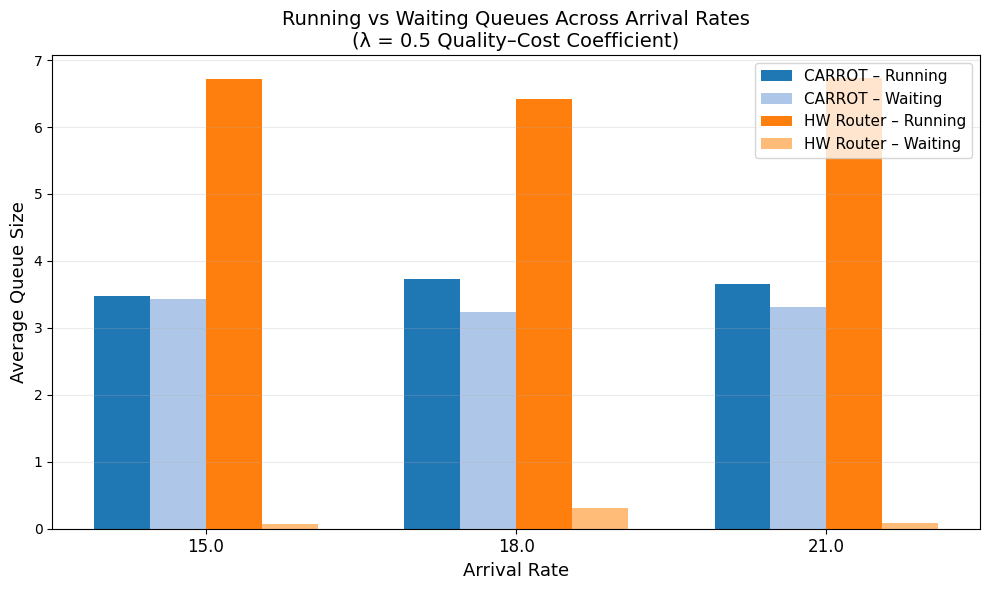

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Unique arrival rates
arrival_rates = sorted(df["arrival_rate"].unique())

# Split by router
carrot = df[df["router"] == "carrot"].sort_values("arrival_rate")
hw     = df[df["router"] == "hw"].sort_values("arrival_rate")

# Extract values
carrot_running = carrot["overall_avg_running"].values
carrot_waiting = carrot["overall_avg_waiting"].values
hw_running     = hw["overall_avg_running"].values
hw_waiting     = hw["overall_avg_waiting"].values

x = np.arange(len(arrival_rates))
width = 0.18  # each bar width

plt.figure(figsize=(10,6))

# --- Bars ---
plt.bar(x - 1.5*width, carrot_running, width, label="CARROT – Running", color="#1f77b4")
plt.bar(x - 0.5*width, carrot_waiting, width, label="CARROT – Waiting", color="#AEC7E8")

plt.bar(x + 0.5*width, hw_running, width, label="HW Router – Running", color="#ff7f0e")
plt.bar(x + 1.5*width, hw_waiting, width, label="HW Router – Waiting", color="#ffbb78")

# --- Labeling ---
plt.xticks(x, arrival_rates, fontsize=12)
plt.xlabel("Arrival Rate", fontsize=13)
plt.ylabel("Average Queue Size", fontsize=13)
plt.title("Running vs Waiting Queues Across Arrival Rates\n(λ = 0.5 Quality–Cost Coefficient)", fontsize=14)

plt.legend(fontsize=11)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


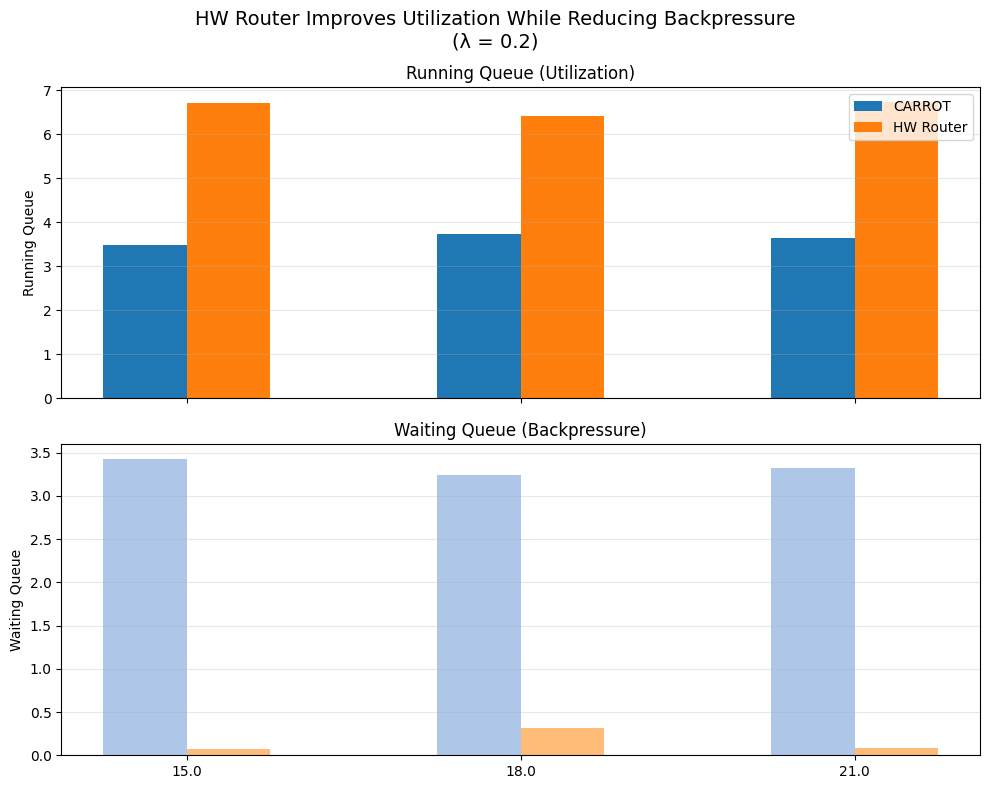

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

x = np.arange(len(arrival_rates))
width = 0.25

# --- Running ---
axes[0].bar(x - width/2, carrot["overall_avg_running"], width, label="CARROT", color="#1f77b4")
axes[0].bar(x + width/2, hw["overall_avg_running"], width, label="HW Router", color="#ff7f0e")
axes[0].set_ylabel("Running Queue")
axes[0].set_title("Running Queue (Utilization)")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Waiting ---
axes[1].bar(x - width/2, carrot["overall_avg_waiting"], width, label="CARROT", color="#AEC7E8")
axes[1].bar(x + width/2, hw["overall_avg_waiting"], width, label="HW Router", color="#ffbb78")
axes[1].set_ylabel("Waiting Queue")
axes[1].set_title("Waiting Queue (Backpressure)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(arrival_rates)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("HW Router Improves Utilization While Reducing Backpressure\n(λ = 0.2)", fontsize=14)
plt.tight_layout()
plt.show()


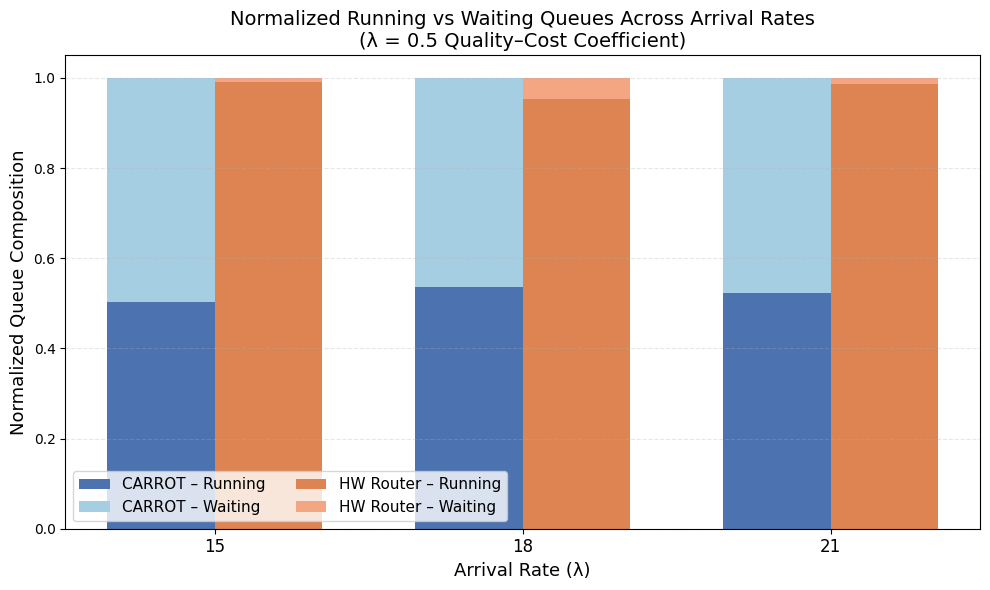

In [54]:
import numpy as np
import matplotlib.pyplot as plt

arrival_rates = sorted(df["arrival_rate"].unique())

carrot = df[df["router"] == "carrot"].sort_values("arrival_rate")
hw     = df[df["router"] == "hw"].sort_values("arrival_rate")

# Normalized
carrot_run   = carrot["overall_avg_running"] / (carrot["overall_avg_running"] + carrot["overall_avg_waiting"])
carrot_wait  = 1 - carrot_run
hw_run       = hw["overall_avg_running"]     / (hw["overall_avg_running"] + hw["overall_avg_waiting"])
hw_wait      = 1 - hw_run

labels = [f"{int(a)}" for a in arrival_rates]
x = np.arange(len(arrival_rates))
width = 0.35

plt.figure(figsize=(10,6))

# === CARROT ===
plt.bar(x - width/2, carrot_run,  width, label="CARROT – Running", color="#4C72B0")
plt.bar(x - width/2, carrot_wait, width, bottom=carrot_run, label="CARROT – Waiting", color="#A6CEE3")

# === HW Router ===
plt.bar(x + width/2, hw_run,  width, label="HW Router – Running", color="#DD8452")
plt.bar(x + width/2, hw_wait, width, bottom=hw_run, label="HW Router – Waiting", color="#F4A582")

plt.xticks(x, labels, fontsize=12)
plt.ylabel("Normalized Queue Composition", fontsize=13)
plt.xlabel("Arrival Rate (λ)", fontsize=13)

plt.title(
    "Normalized Running vs Waiting Queues Across Arrival Rates\n"
    "(λ = 0.5 Quality–Cost Coefficient)",
    fontsize=14
)

plt.legend(fontsize=11, ncol=2)
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


In [55]:
gpu_cols = [
    "arrival_rate",
    "router_pretty",
    "gpu_0_avg_running",
    "gpu_1_avg_running",
    "overall_avg_running"
]

gpu_table = df[gpu_cols].sort_values(["arrival_rate", "router_pretty"])
gpu_table


,arrival_rate,router_pretty,gpu_0_avg_running,gpu_1_avg_running,overall_avg_running
0,15.0,CARROT,0.000000,5.792683,3.475610
3,15.0,HW-Router,1.008197,10.535519,6.724590
1,18.0,CARROT,0.000000,6.222222,3.733333
4,18.0,HW-Router,0.939394,10.060606,6.412121
2,21.0,CARROT,0.000000,6.084388,3.650633
5,21.0,HW-Router,0.959016,10.584699,6.734426


In [56]:
kv_cols = [
    "arrival_rate",
    "router_pretty",
    "model_Qwen2.5-14B-Instruct_avg_kv_cache",
    "model_Phi-3-mini-128k-instruct_avg_kv_cache",
    "model_Llama-3.1-8B-Instruct_avg_kv_cache",
    "model_Qwen2.5-3B-Instruct_avg_kv_cache",
    "model_Mistral-7B-Instruct-v0.3_avg_kv_cache",
    "overall_avg_kv_cache"
]

kv_table = df[kv_cols].sort_values(["arrival_rate", "router_pretty"])
kv_table


,arrival_rate,router_pretty,model_Qwen2.5-14B-Instruct_avg_kv_cache,model_Phi-3-mini-128k-instruct_avg_kv_cache,model_Llama-3.1-8B-Instruct_avg_kv_cache,model_Qwen2.5-3B-Instruct_avg_kv_cache,model_Mistral-7B-Instruct-v0.3_avg_kv_cache,overall_avg_kv_cache
0,15.0,CARROT,0.0,0.000000,0.836998,0.012924,0.000076,0.170000
3,15.0,HW-Router,0.0,0.515744,0.000000,0.289029,0.278535,0.216662
1,18.0,CARROT,0.0,0.000000,0.839854,0.015128,0.000018,0.171000
4,18.0,HW-Router,0.0,0.534869,0.000000,0.354460,0.216770,0.221220
2,21.0,CARROT,0.0,0.000000,0.843083,0.013062,0.000028,0.171235
5,21.0,HW-Router,0.0,0.496376,0.000000,0.359399,0.242057,0.219566


In [57]:
model_kv_cols = [
    "model_Qwen2.5-14B-Instruct_avg_kv_cache",
    "model_Phi-3-mini-128k-instruct_avg_kv_cache",
    "model_Llama-3.1-8B-Instruct_avg_kv_cache",
    "model_Qwen2.5-3B-Instruct_avg_kv_cache",
    "model_Mistral-7B-Instruct-v0.3_avg_kv_cache"
]

df["kv_cache_std"] = df[model_kv_cols].std(axis=1)

imbalance_table = df[[
    "arrival_rate",
    "router_pretty",
    "kv_cache_std"
]].sort_values(["arrival_rate", "router_pretty"])

imbalance_table


,arrival_rate,router_pretty,kv_cache_std
0,15.0,CARROT,0.372906
3,15.0,HW-Router,0.219317
1,18.0,CARROT,0.373958
4,18.0,HW-Router,0.231314
2,21.0,CARROT,0.375617
5,21.0,HW-Router,0.219716


In [58]:
waiting_cols = [
    "arrival_rate",
    "router_pretty",
    "gpu_0_avg_waiting",
    "gpu_1_avg_waiting",
    "overall_avg_waiting"
]

waiting_table = df[waiting_cols].sort_values(["arrival_rate", "router_pretty"])
waiting_table


,arrival_rate,router_pretty,gpu_0_avg_waiting,gpu_1_avg_waiting,overall_avg_waiting
0,15.0,CARROT,0.000000,5.709350,3.425610
3,15.0,HW-Router,0.172131,0.000000,0.068852
1,18.0,CARROT,0.000000,5.397778,3.238667
4,18.0,HW-Router,0.780303,0.000000,0.312121
2,21.0,CARROT,0.000000,5.529536,3.317722
5,21.0,HW-Router,0.213115,0.005464,0.088525


In [59]:
gpu_dispatch_cols = [
    "arrival_rate",
    "router_pretty",
    "dispatch_count_gpu_0",
    "dispatch_count_gpu_1"
]

gpu_dispatch = df[gpu_dispatch_cols].sort_values(["arrival_rate", "router_pretty"])

# Optional: add percentages for clarity
gpu_dispatch["gpu_0_pct"] = (
    gpu_dispatch["dispatch_count_gpu_0"] /
    (gpu_dispatch["dispatch_count_gpu_0"] + gpu_dispatch["dispatch_count_gpu_1"])
).round(3)

gpu_dispatch["gpu_1_pct"] = (
    gpu_dispatch["dispatch_count_gpu_1"] /
    (gpu_dispatch["dispatch_count_gpu_0"] + gpu_dispatch["dispatch_count_gpu_1"])
).round(3)

gpu_dispatch


,arrival_rate,router_pretty,dispatch_count_gpu_0,dispatch_count_gpu_1,gpu_0_pct,gpu_1_pct
0,15.0,CARROT,0,300,0.000,1.000
3,15.0,HW-Router,33,267,0.110,0.890
1,18.0,CARROT,0,300,0.000,1.000
4,18.0,HW-Router,25,275,0.083,0.917
2,21.0,CARROT,0,300,0.000,1.000
5,21.0,HW-Router,37,263,0.123,0.877


In [60]:
import pandas as pd

# Select relevant columns
cols = [
    "arrival_rate", "router",
    
    "gpu_0_avg_running", "gpu_1_avg_running",
    "gpu_0_avg_waiting", "gpu_1_avg_waiting",
    "gpu_0_avg_kv_cache", "gpu_1_avg_kv_cache",
]

gpu_df = df[cols].copy()

# Pretty router names
gpu_df["router_pretty"] = gpu_df["router"].map({
    "carrot": "CARROT",
    "hw": "HW-Router"
})

# Compute imbalance metrics
gpu_df["running_diff"] = (gpu_df["gpu_0_avg_running"] - gpu_df["gpu_1_avg_running"]).abs()
gpu_df["waiting_diff"] = (gpu_df["gpu_0_avg_waiting"] - gpu_df["gpu_1_avg_waiting"]).abs()
gpu_df["kv_diff"] = (gpu_df["gpu_0_avg_kv_cache"] - gpu_df["gpu_1_avg_kv_cache"]).abs()

# Order columns for clarity
gpu_df = gpu_df[
    [
        "arrival_rate", "router_pretty",
        "gpu_0_avg_running", "gpu_1_avg_running",
        "gpu_0_avg_waiting", "gpu_1_avg_waiting",
        "gpu_0_avg_kv_cache", "gpu_1_avg_kv_cache",
        "running_diff", "waiting_diff", "kv_diff"
    ]
]

gpu_df.sort_values(["arrival_rate", "router_pretty"])


,arrival_rate,router_pretty,gpu_0_avg_running,gpu_1_avg_running,gpu_0_avg_waiting,gpu_1_avg_waiting,gpu_0_avg_kv_cache,gpu_1_avg_kv_cache,running_diff,waiting_diff,kv_diff
0,15.0,CARROT,0.000000,5.792683,0.000000,5.709350,0.000000,0.283333,5.792683,5.709350,0.283333
3,15.0,HW-Router,1.008197,10.535519,0.172131,0.000000,0.257872,0.189188,9.527322,0.172131,0.068684
1,18.0,CARROT,0.000000,6.222222,0.000000,5.397778,0.000000,0.285000,6.222222,5.397778,0.285000
4,18.0,HW-Router,0.939394,10.060606,0.780303,0.000000,0.267435,0.190410,9.121212,0.780303,0.077025
2,21.0,CARROT,0.000000,6.084388,0.000000,5.529536,0.000000,0.285391,6.084388,5.529536,0.285391
5,21.0,HW-Router,0.959016,10.584699,0.213115,0.005464,0.248188,0.200485,9.625683,0.207650,0.047703


In [61]:
import pandas as pd

# EDIT THIS based on your gpu_model_map_h100.yaml
gpu_model_map = {
    "GPU0": ["Qwen2.5-14B-Instruct", "Mistral-7B-Instruct-v0.3"],
    "GPU1": ["Llama-3.1-8B-Instruct", "Qwen2.5-3B-Instruct", "Phi-3-mini-128k-instruct"]
}

gpu_model_table = pd.DataFrame([
    {"GPU": gpu, "Models_Placed": ", ".join(models), "Num_Models": len(models)}
    for gpu, models in gpu_model_map.items()
])

gpu_model_table


,GPU,Models_Placed,Num_Models
0,GPU0,"Qwen2.5-14B-Instruct, Mistral-7B-Instruct-v0.3",2
1,GPU1,"Llama-3.1-8B-Instruct, Qwen2.5-3B-Instruct, Ph...",3


In [62]:
gpu_dispatch = df[[
    "arrival_rate", "router_pretty", 
    "dispatch_count_gpu_0", "dispatch_count_gpu_1"
]].copy()

# Add % share for GPU0
gpu_dispatch["gpu0_share"] = (
    gpu_dispatch["dispatch_count_gpu_0"] /
    (gpu_dispatch["dispatch_count_gpu_0"] + gpu_dispatch["dispatch_count_gpu_1"])
).round(3)

gpu_dispatch.sort_values(["arrival_rate", "router_pretty"])


,arrival_rate,router_pretty,dispatch_count_gpu_0,dispatch_count_gpu_1,gpu0_share
0,15.0,CARROT,0,300,0.000
3,15.0,HW-Router,33,267,0.110
1,18.0,CARROT,0,300,0.000
4,18.0,HW-Router,25,275,0.083
2,21.0,CARROT,0,300,0.000
5,21.0,HW-Router,37,263,0.123


In [42]:
model_cols = [c for c in df.columns if c.startswith("dispatch_count_model_")]

model_dispatch = df[["arrival_rate", "router_pretty"] + model_cols].copy()

# Convert model columns to human readable names:
model_dispatch.rename(columns={
    col: col.replace("dispatch_count_model_", "")
    for col in model_cols
}, inplace=True)

model_dispatch.sort_values(["arrival_rate", "router_pretty"])


,arrival_rate,router_pretty,Qwen2.5-3B-Instruct,Llama-3.1-8B-Instruct,Mistral-7B-Instruct-v0.3
0,15.0,CARROT,133,66,1
3,15.0,HW-Router,101,0,80
1,18.0,CARROT,133,66,1
4,18.0,HW-Router,101,0,77
2,21.0,CARROT,133,66,1
5,21.0,HW-Router,94,0,85


In [43]:
gpu_dispatch["gpu_imbalance"] = (
    (gpu_dispatch["dispatch_count_gpu_0"] - gpu_dispatch["dispatch_count_gpu_1"]).abs()
    / (gpu_dispatch["dispatch_count_gpu_0"] + gpu_dispatch["dispatch_count_gpu_1"])
).round(3)

gpu_dispatch.sort_values(["arrival_rate", "router_pretty"])


,arrival_rate,router_pretty,dispatch_count_gpu_0,dispatch_count_gpu_1,gpu0_share,gpu_imbalance
0,15.0,CARROT,0,200,0.000,1.00
3,15.0,HW-Router,19,181,0.095,0.81
1,18.0,CARROT,0,200,0.000,1.00
4,18.0,HW-Router,22,178,0.110,0.78
2,21.0,CARROT,0,200,0.000,1.00
5,21.0,HW-Router,21,179,0.105,0.79


In [44]:
import numpy as np

def compute_model_imbalance(row):
    counts = []
    for col in model_cols:
        counts.append(row[col])
    counts = np.array(counts)
    if counts.sum() == 0:
        return 0
    return (counts.std() / counts.mean()).round(3)

df["model_imbalance"] = df.apply(compute_model_imbalance, axis=1)
df_model_imb = df[["arrival_rate", "router_pretty", "model_imbalance"]]
df_model_imb


,arrival_rate,router_pretty,model_imbalance
0,15.0,CARROT,0.808
1,18.0,CARROT,0.808
2,21.0,CARROT,0.808
3,15.0,HW-Router,0.721
4,18.0,HW-Router,0.726
5,21.0,HW-Router,0.710


In [46]:
df["router_pretty"] = df["router"].replace({
    "carrot": "CARROT",
    "hw": "HW-Router"
})


In [47]:
df["gpu_imbalance"] = (
    (df["dispatch_count_gpu_0"] - df["dispatch_count_gpu_1"]).abs() /
    (df["dispatch_count_gpu_0"] + df["dispatch_count_gpu_1"])
).round(3)


In [48]:
model_cols = [c for c in df.columns if c.startswith("dispatch_count_model_")]

import numpy as np

def compute_model_imbalance(row):
    counts = np.array([row[c] for c in model_cols])
    total = counts.sum()
    if total == 0:
        return 0
    return (counts.std() / counts.mean()).round(3)

df["model_imbalance"] = df.apply(compute_model_imbalance, axis=1)


In [49]:
summary = df[[
    "arrival_rate", "router_pretty",
    "dispatch_count_gpu_0", "dispatch_count_gpu_1",
    "gpu_imbalance", "model_imbalance"
]].sort_values(["arrival_rate", "router_pretty"])

summary


,arrival_rate,router_pretty,dispatch_count_gpu_0,dispatch_count_gpu_1,gpu_imbalance,model_imbalance
0,15.0,CARROT,0,200,1.00,0.808
3,15.0,HW-Router,19,181,0.81,0.721
1,18.0,CARROT,0,200,1.00,0.808
4,18.0,HW-Router,22,178,0.78,0.726
2,21.0,CARROT,0,200,1.00,0.808
5,21.0,HW-Router,21,179,0.79,0.710
